# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
df = pd.read_csv('iris.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (150, 6)

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
# Informasi dataset
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.60000

In [7]:
# Cek missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


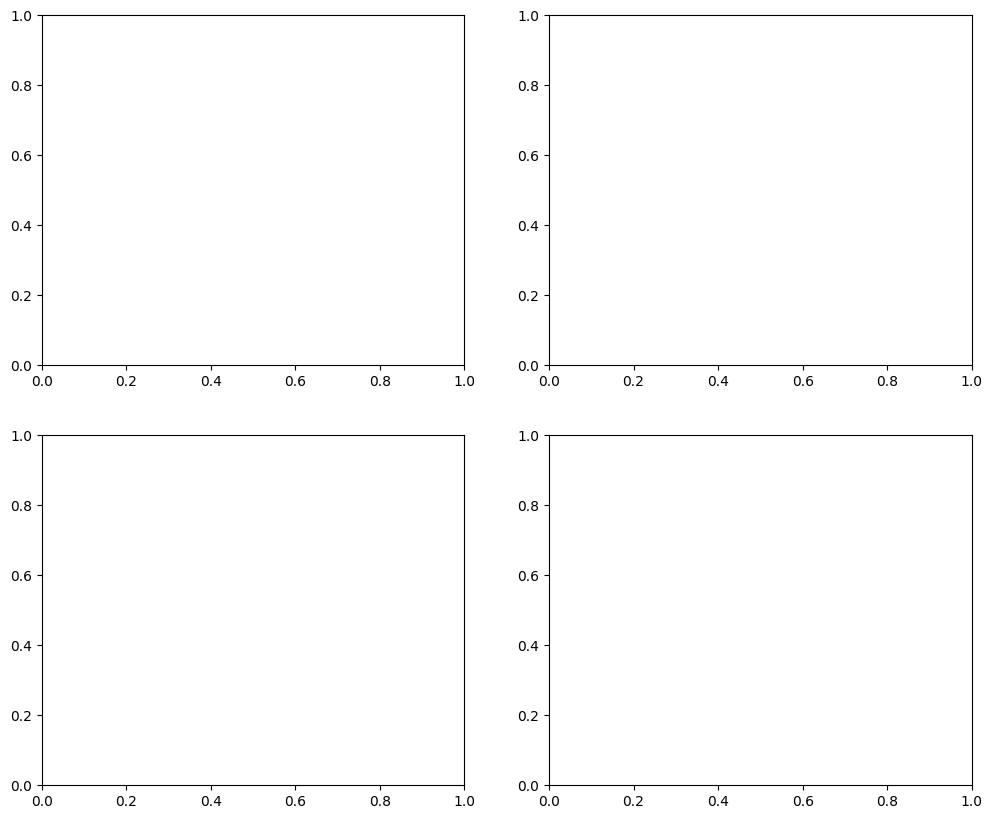

In [8]:
# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

In [9]:
# Distribution plot untuk numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numerical_cols[:4]):
    row, col_idx = i // 2, i % 2
    axes[row, col_idx].hist(df[col], bins=20, edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution of {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_distribution.png')
plt.show()

<Figure size 640x480 with 0 Axes>

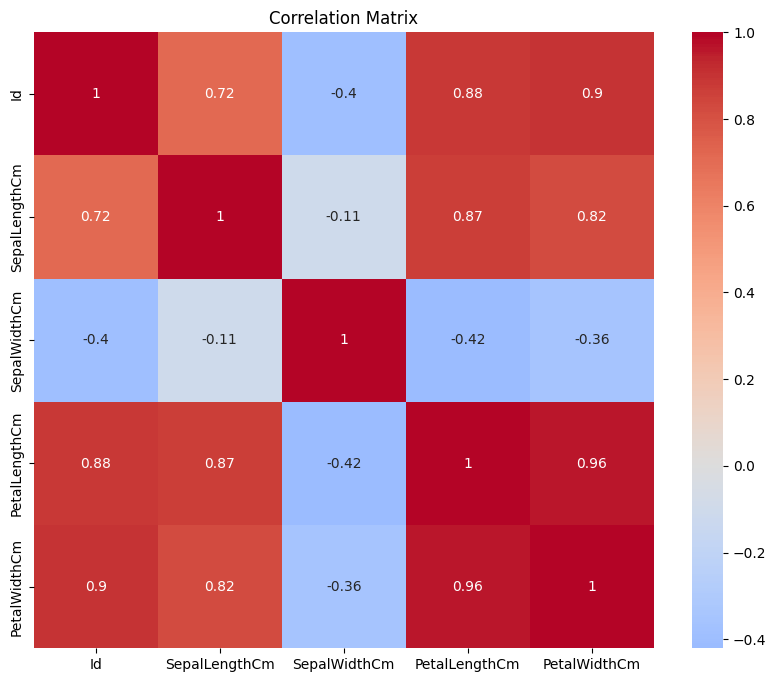

In [10]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation = df[numerical_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
possible_targets = ['species', 'target', 'class', 'label', 'Category']
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    # Jika tidak ditemukan, asumsikan kolom terakhir adalah target
    target_col = df.columns[-1]
    print(f"Target column tidak terdeteksi, menggunakan kolom terakhir: {target_col}")

print(f"\nTarget column: {target_col}")
print(f"Feature columns: {df.columns.drop(target_col).tolist()}")

# Pisahkan X dan y
X = df.drop(target_col, axis=1)
y = df[target_col]

print(f"\nShape X (fitur): {X.shape}")
print(f"Shape y (target): {y.shape}")

Target column tidak terdeteksi, menggunakan kolom terakhir: Species

Target column: Species
Feature columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Shape X (fitur): (150, 5)
Shape y (target): (150,)


In [12]:
# Cek missing values di X
if X.isnull().sum().sum() > 0:
    print("Ada missing values! Mengisi dengan mean...")
    imputer = SimpleImputer(strategy='mean')
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    print("Missing values telah diisi")
else:
    X_imputed = X
    print("Tidak ada missing values")

Tidak ada missing values


In [13]:
categorical_cols = X_imputed.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    print(f"Kolom kategorikal ditemukan: {categorical_cols.tolist()}")
    for col in categorical_cols:
        le = LabelEncoder()
        X_imputed[col] = le.fit_transform(X_imputed[col].astype(str))
        print(f"  - {col} telah diencode")
else:
    print("Tidak ada kolom kategorikal")

Tidak ada kolom kategorikal


In [14]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)
print("Data telah dinormalisasi (StandardScaler)")
print(f"Range data setelah scaling: [{X_scaled.min().min():.2f}, {X_scaled.max().max():.2f}]")

Data telah dinormalisasi (StandardScaler)
Range data setelah scaling: [-2.44, 3.11]


In [15]:
if y.dtype == 'object':
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    print(f"Target telah diencode")
    print(f"Unique classes: {label_encoder.classes_}")
else:
    y_encoded = y.values if isinstance(y, pd.Series) else y
    label_encoder = None
    print("Target sudah dalam bentuk numerik")


Target telah diencode
Unique classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42,
    stratify=y_encoded if len(np.unique(y_encoded)) > 1 else None
)

print(f"Training set size: {X_train.shape}")
print(f"  - X_train: {X_train.shape[0]} samples")
print(f"  - y_train: {y_train.shape[0]} samples")
print(f"Test set size: {X_test.shape}")
print(f"  - X_test: {X_test.shape[0]} samples")
print(f"  - y_test: {y_test.shape[0]} samples")

Training set size: (120, 5)
  - X_train: 120 samples
  - y_train: 120 samples
Test set size: (30, 5)
  - X_test: 30 samples
  - y_test: 30 samples


In [17]:
# Buat folder untuk menyimpan hasil
import os
os.makedirs('dataset_preprocessing', exist_ok=True)

# Simpan data
pd.DataFrame(X_train).to_csv('dataset_preprocessing/X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('dataset_preprocessing/X_test.csv', index=False)
pd.DataFrame(y_train).to_csv('dataset_preprocessing/y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('dataset_preprocessing/y_test.csv', index=False)

# Simpan scaler dan encoder untuk digunakan nanti saat inference
import joblib
joblib.dump(scaler, 'dataset_preprocessing/scaler.pkl')
if label_encoder:
    joblib.dump(label_encoder, 'dataset_preprocessing/label_encoder.pkl')

print("✓ X_train.csv disimpan")
print("✓ X_test.csv disimpan")
print("✓ y_train.csv disimpan")
print("✓ y_test.csv disimpan")
print("✓ scaler.pkl disimpan")
if label_encoder:
    print("✓ label_encoder.pkl disimpan")

print("\n" + "="*50)
print("PREPROCESSING SELESAI!")
print("="*50)
print(f"Total samples: {len(X_scaled)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(X_scaled)*100:.1f}%)")
print(f"Number of features: {X_scaled.shape[1]}")
print(f"Number of classes: {len(np.unique(y_encoded))}")

✓ X_train.csv disimpan
✓ X_test.csv disimpan
✓ y_train.csv disimpan
✓ y_test.csv disimpan
✓ scaler.pkl disimpan
✓ label_encoder.pkl disimpan

PREPROCESSING SELESAI!
Total samples: 150
Training samples: 120 (80.0%)
Test samples: 30 (20.0%)
Number of features: 5
Number of classes: 3
